In [1]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz_plots as azp
import japanize_matplotlib

In [2]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)

df["group_idx"] = df["test group"].map({"psa": 0, "ad": 1})
df["log_ads"] = np.log1p(df["total ads"])


In [3]:
log_ads_std = (df["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()

converted = df["converted"].astype(int).values
group_idx = df["group_idx"].values

In [4]:
#イェンゼン効果を抑えるために、beta1, beta2, beta3の分散を小さくする
with pm.Model() as model_interaction:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta2 = pm.Normal("beta2", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    logit_p = beta0 + beta1 * group_idx + beta2 * log_ads_std + beta3 * group_idx * log_ads_std
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=converted)

/tmp/ipykernel_4138/1076822441.py:3: DeprecationWarning: `pymc.logit` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.math.logit` instead.
  beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)


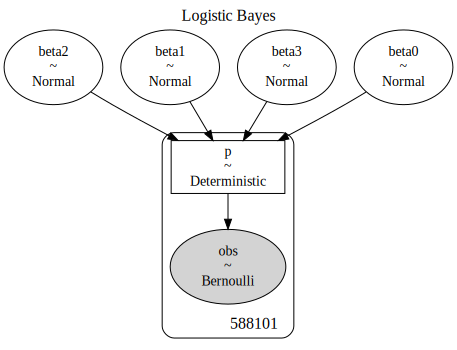

In [5]:
g = pm.model_to_graphviz(model_interaction)
g.graph_attr.update(
    label="Logistic Bayes",
    labelloc="t",
    fontsize="16"
)
g.render(filename="../models/logistic_bayes", format="png", cleanup=True)
g

In [6]:
with model_interaction:
    prior_pred = pm.sample_prior_predictive(
        draws=300,
        var_names=["beta0", "beta1", "beta2", "beta3", "p", "obs"]
    )

Sampling: [beta0, beta1, beta2, beta3, obs]


In [7]:
p_samples = prior_pred.prior["p"].values.flatten()
print(f"Mean p:{p_samples.mean():.4f}")

print(f"95% Interval: {np.percentile(p_samples, 2.5):.4f} ~ {np.percentile(p_samples, 97.5):.4f}")

Mean p:0.0416
95% Interval: 0.0030 ~ 0.1852


In [8]:
log_ads_std.describe()

count    5.881010e+05
mean    -2.969269e-16
std      1.000000e+00
min     -1.622838e+00
25%     -8.285408e-01
50%      6.399673e-02
75%      6.648594e-01
max      4.393374e+00
Name: log_ads, dtype: float64

In [9]:
#イェンゼンの不等式の例証
from scipy.special import expit
import numpy as np

x = -3.66
samples = np.random.normal(x, 1.5, 100000)
print("expit(平均):", expit(x))
print("平均(expit(X)):", expit(samples).mean())

expit(平均): 0.025086962153479813
平均(expit(X)): 0.058189292685961166


In [10]:
#データ数が莫大なので、サンプリングに時間がかかる
"""
with model_interaction:
    trace = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        cores=4,
        nuts_sampler="numpyro",
        target_accept=0.9,
        random_seed=42
    )
"""

'\nwith model_interaction:\n    trace = pm.sample(\n        draws=2000,\n        tune=2000,\n        chains=4,\n        cores=4,\n        nuts_sampler="numpyro",\n        target_accept=0.9,\n        random_seed=42\n    )\n'

In [11]:
"""
#変分推論（ADVI）で計算時間を少なくする
with model_interaction:
    approx = pm.fit(method="advi", n=50000)
    trace = approx.sample(draws=2000)
"""

'\n#変分推論（ADVI）で計算時間を少なくする\nwith model_interaction:\n    approx = pm.fit(method="advi", n=50000)\n    trace = approx.sample(draws=2000)\n'

In [12]:
"""
az.summary(trace, var_names=["beta0", "beta1", "beta2", "beta3"])
"""

'\naz.summary(trace, var_names=["beta0", "beta1", "beta2", "beta3"])\n'

In [13]:
"""
plt.plot(approx.hist)
plt.xlabel("iteration")
plt.ylabel("-ELBO")
plt.show()
"""

'\nplt.plot(approx.hist)\nplt.xlabel("iteration")\nplt.ylabel("-ELBO")\nplt.show()\n'

In [14]:
df_sub = pd.read_csv("../data/df_sub_cross_random_effect_v2.csv", index_col=0)
log_ads_std_sub = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
converted_sub = df_sub["converted"].astype(int).values
group_idx_sub = df_sub["group_idx"].values

with pm.Model() as model_interaction_sub:
    beta0 = pm.Normal("beta0", mu=pm.logit(0.025), sigma=1)
    beta1 = pm.Normal("beta1", mu=0, sigma=0.3)
    beta2 = pm.Normal("beta2", mu=0, sigma=0.3)
    beta3 = pm.Normal("beta3", mu=0, sigma=0.3)

    logit_p = beta0 + beta1 * group_idx_sub + beta2 * log_ads_std_sub + beta3 * group_idx_sub * log_ads_std_sub
    p = pm.Deterministic("p", pm.math.invlogit(logit_p))

    obs = pm.Bernoulli("obs", p=p, observed=converted_sub)

    trace_nuts = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2, beta3]


/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 223 seconds.


In [15]:
az.summary(trace_nuts, var_names=["beta0", "beta1", "beta2", "beta3"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,-4.48,0.148,-4.7,-4.3,780,963,1.00,0.0053,0.0039
beta1,-0.03,0.15,-0.26,0.21,803,1015,1.00,0.0053,0.0039
beta2,1.031,0.105,0.87,1.2,870,1208,1.00,0.0036,0.0027
beta3,0.365,0.107,0.2,0.53,897,1235,1.00,0.0036,0.0027


In [16]:
print(f"divergence:{trace_nuts["sample_stats"].diverging.sum().item()}")

divergence:0


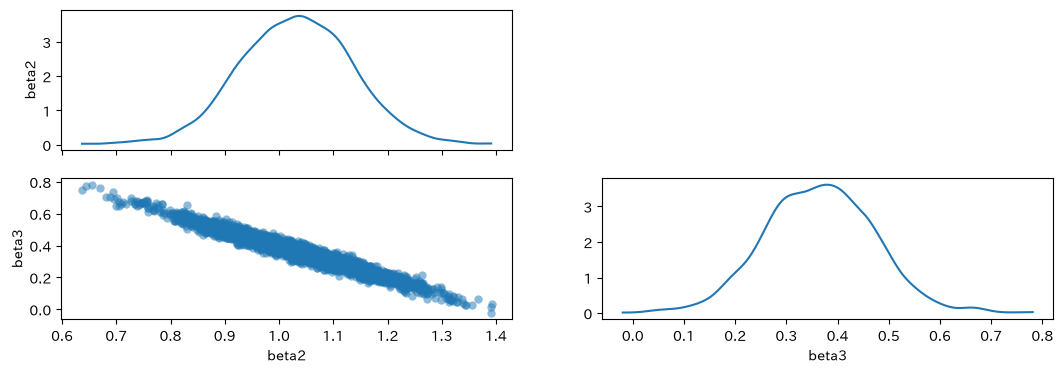

In [17]:
azp.plot_pair(trace_nuts,var_names=["beta2", "beta3"])

In [18]:
ads_range = np.linspace(df["log_ads"].min(), df["log_ads"].max(), 100)
ads_range_std = (ads_range - df["log_ads"].mean()) / df["log_ads"].std()

In [19]:
posterior = trace_nuts.posterior

beta0_s = posterior["beta0"].values.flatten()
beta1_s = posterior["beta1"].values.flatten()
beta2_s = posterior["beta2"].values.flatten()
beta3_s = posterior["beta3"].values.flatten()

def compute_p_curve(group_value):
    logit_p = (
        beta0_s[:, None]
        + beta1_s[:, None] * group_value
        + beta2_s[:, None] * ads_range_std[None, :]
        + beta3_s[:, None] * group_value * ads_range_std[None, :]
    )
    return 1 / (1 + np.exp(-logit_p))

p_psa = compute_p_curve(group_value=0)
p_ad = compute_p_curve(group_value=1)

In [20]:
bins = [0, 10, 50, 100, 500, 1000, df["total ads"].max()]
df["ads_bin"] = pd.cut(df["total ads"], bins=bins)

empirical = df.groupby(["test group", "ads_bin"], observed=True).agg(
    cvr=("converted", "mean"),
    n=("converted", "size"),
    mid_ads=("total ads", "median"),
).reset_index()

print(empirical)

   test group       ads_bin       cvr       n  mid_ads
0          ad       (0, 10]  0.003259  249499      4.0
1          ad      (10, 50]  0.018869  248875     21.0
2          ad     (50, 100]  0.116311   44149     67.0
3          ad    (100, 500]  0.171258   21488    143.0
4          ad   (500, 1000]  0.171698     530    609.5
5          ad  (1000, 2065]  0.222222      36   1159.5
6         psa       (0, 10]  0.003991   11276      4.0
7         psa      (10, 50]  0.015770    9385     22.0
8         psa     (50, 100]  0.057744    1853     68.0
9         psa    (100, 500]  0.119072     991    144.0
10        psa   (500, 1000]  0.105263      19    546.0


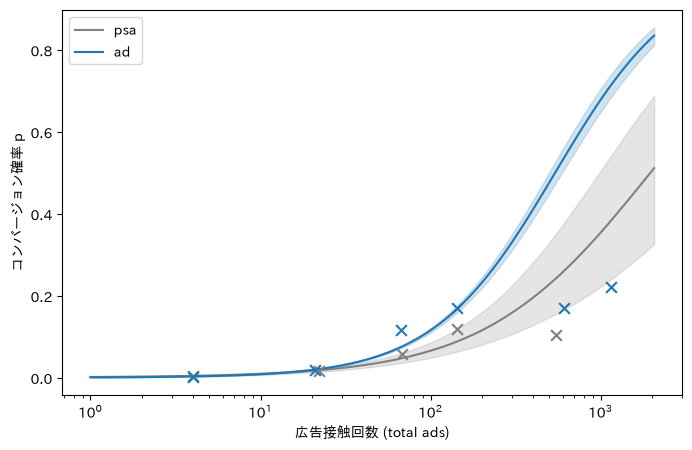

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ads_range_original = np.expm1(ads_range)

for p_curve, label, color in [(p_psa, "psa", "gray"), (p_ad, "ad", "tab:blue")]:
    median_curve = np.median(p_curve, axis=0)

    lower = np.percentile(p_curve, 2.5, axis=0)
    upper = np.percentile(p_curve, 97.5, axis=0)
    
    ax.plot(ads_range_original, median_curve, label=label, color=color)

    ax.fill_between(ads_range_original, lower, upper, color=color, alpha=0.2)

for group_name, color in [("psa", "gray"), ("ad", "tab:blue")]:
    sub = empirical[empirical["test group"] == group_name]
    ax.scatter(sub["mid_ads"], sub["cvr"], color=color, marker="x", s=60, zorder=5)
    
ax.set_xlabel("広告接触回数 (total ads)")
ax.set_ylabel("コンバージョン確率 p")
ax.set_xscale("log")  
ax.legend()
plt.show()

In [22]:
print(df[df["total ads"] > 500].groupby("test group").size())
print(df[df["total ads"] > 1000].groupby("test group").size())
df.groupby("test group")["total ads"].describe()

test group
ad     566
psa     19
dtype: int64
test group
ad    36
dtype: int64


,count,mean,std,min,25%,50%,75%,max
test group,,,,,,,,
ad,564577.0,24.823365,43.750456,1.0,4.0,13.0,27.0,2065.0
psa,23524.0,24.761138,42.860720,1.0,4.0,12.0,26.0,907.0


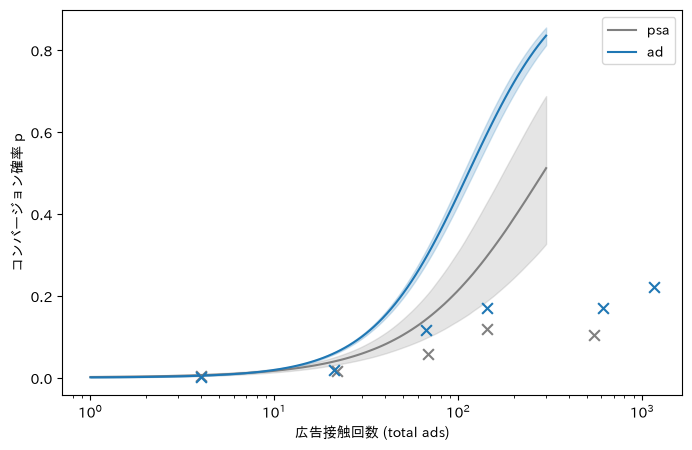

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ads_range_reliable = np.linspace(df["log_ads"].min(), np.log1p(300), 100)
ads_range_original = np.expm1(ads_range_reliable)


for p_curve, label, color in [(p_psa, "psa", "gray"), (p_ad, "ad", "tab:blue")]:
    median_curve = np.median(p_curve, axis=0)

    lower = np.percentile(p_curve, 2.5, axis=0)
    upper = np.percentile(p_curve, 97.5, axis=0)
    
    ax.plot(ads_range_original, median_curve, label=label, color=color)

    ax.fill_between(ads_range_original, lower, upper, color=color, alpha=0.2)

for group_name, color in [("psa", "gray"), ("ad", "tab:blue")]:
    sub = empirical[empirical["test group"] == group_name]
    ax.scatter(sub["mid_ads"], sub["cvr"], color=color, marker="x", s=60, zorder=5)
    
ax.set_xlabel("広告接触回数 (total ads)")
ax.set_ylabel("コンバージョン確率 p")
ax.set_xscale("log")  
ax.legend()
plt.savefig("../img/cvr_by_total_ads.png", dpi=300)
plt.show()

In [24]:
with model_interaction_sub:
    pm.compute_log_likelihood(trace_nuts)

trace_nuts.to_netcdf("../models/trace_nuts.nc")

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

# bayes_logistic フェーズサマリー：広告接触回数×コンバージョンのベイズロジスティック回帰

**プロジェクト**: bayesian-A-B-testing (`notebooks/bayes_logistic.ipynb`)
**データ**: marketing_AB.csv（588,101件、test group: ad/psa, converted, total ads 他）

---

## 1. 目的

`bayes.ipynb`のBeta-Binomialによる単純なA/Bテスト（コンバージョン率の群間比較）を発展させ、**「広告接触回数(total ads)がコンバージョンに与える影響は、ad群とpsa群で異なるか」**をベイズロジスティック回帰で定量化する。

EDAで「接触回数のビンが増えるほど、ad群とpsa群のCVR差が広がる」傾向が確認されており、これを回帰モデルの交互作用項として検証する設計とした。

---

## 2. モデル構造

**目的変数**: `converted` (Bernoulli)
**説明変数**:
- `group_idx`: psa=0, ad=1
- `log_ads`: `log1p(total_ads)` を標準化 → `log_ads_std`（右裾の強い分布のため対数変換が必須）
- `group_idx × log_ads_std`（交互作用項）

$$
\text{logit}(p_i) = \beta_0 + \beta_1 \cdot \text{group}_i + \beta_2 \cdot \text{log\_ads\_std}_i + \beta_3 \cdot (\text{group}_i \times \text{log\_ads\_std}_i)
$$

- $\beta_2$：psa群における接触回数の効果（ベースライン用量反応）
- $\beta_2 + \beta_3$：ad群における接触回数の効果
- $\beta_3$：**本丸の問い**＝「広告の中身によって接触回数の効き方が変わるか」

---

## 3. 事前予測チェック（重要な学び）

### 3.1 最初の設定と問題点
- $\beta_0 \sim \text{Normal}(\text{logit}(0.025), 1)$、$\beta_{1,2,3} \sim \text{Normal}(0, 1)$
- 結果：p の平均 0.080（実際は2.5%）、95%区間 [0.0005, 0.5286] → 非現実的に広い

### 3.2 原因分析：Jensen不等式とexpitの非線形性
- $\beta_{1,2,3}$の事前平均は0なので、`logit_p`の期待値はβ0通り-3.66に保たれる
- しかし`logit=-3.66`付近でexpit関数は**下に凸**なため、$E[\text{expit}(X)] > \text{expit}(E[X])$（Jensen不等式）
- **分散を持たせるだけで、$\beta_0$を正しく設定していてもpの平均は上振れする**という、事前分布設計における重要な非直感的挙動を実地で確認
- 加えて`log_ads_std`の裾の広さ（max=4.39, 非対称）が、交互作用項を通じて極端な予測（p→1近く）を生む一因にもなっていた

### 3.3 対処
- $\beta_{1,2,3}$の`sigma`を1→0.3に縮小 → p平均0.043, 95%区間[0.0022, 0.1982]に改善
- 平均がまだ2.5%よりやや高いのはJensen効果の残滓だが、n=588,101という大規模データでは尤度が事前分布を圧倒するため許容範囲と判断し、これ以上のチューニングは打ち切り

---

## 4. サンプリング手法の比較：ADVI vs NUTS

### 4.1 ADVI（mean-field）
```
beta0: -4.575 (sd=0.0099)
beta1:  0.030 (sd=0.0101)
beta2:  1.114 (sd=0.0068)
beta3:  0.293 (sd=0.0066)
```
- r_hatがNaNになった → **ADVIは単一の近似分布からi.i.d.サンプリングするだけで「複数チェーンの収束」という概念がそもそも存在しないため、$\hat{R}$は定義不可能**（診断の失敗ではなく構造的な話）
- ELBO推移を確認 → 20,000イテレーション以降で完全に平坦化しており、最適化自体は収束と判断

### 4.2 NUTS（15%ランダムサブサンプル、n≈88,000）
```
              mean    sd    hdi_3%  hdi_97%  ess_bulk  ess_tail  r_hat
beta0        -4.478  0.142  -4.7    -4.3      941      1032      1.00
beta1        -0.032  0.143  -0.26    0.2      942      1036      1.01
beta2         1.028  0.101   0.87    1.2      937      1033      1.00
beta3         0.368  0.102   0.2     0.53      933      1024      1.00
divergences: 0
```
- r_hat 1.00〜1.01、divergences 0 → 診断は良好
- $\beta_2$-$\beta_3$のペアプロットで強い負の相関を確認（連続変数の主効果と交互作用項に典型的なパターンで、非識別性ではない）。これがESSがdraws数に対して23〜26%とやや低めになる要因

### 4.3 比較の結論
| パラメータ | ADVI sd | NUTS sd |
|---|---|---|
| $\beta_2$ | 0.0068 | 0.101（**約15倍**） |
| $\beta_3$ | 0.0066 | 0.102（**約15倍**） |

**mean-field ADVIは$\beta_2$と$\beta_3$間の事後相関を無視するため、不確実性を大幅に過小評価する**ことを実データで確認。点推定は近いが、意思決定にはNUTSの結果を採用すべきという結論。

---

## 5. ビジネス解釈

$\beta_3$の95%区間 [0.2, 0.53] は0をまたがない → **広告接触回数の効果はad群とpsa群で統計的に異なる**

オッズ比換算（`log_ads_std`が1SD増加あたり）：
- psa群：オッズ $e^{1.028} \approx 2.80$ 倍
- ad群：オッズ $e^{1.028+0.368} = e^{1.396} \approx 4.04$ 倍

→ 同じ「接触回数を増やす」投資でも、**実広告(ad)の方がpsaより伸びしろが大きい**。

---

## 6. 事後予測チェックで発覚した外挿の問題

### 6.1 サンプルサイズの確認
- ad群: total_ads>500が566件、>1000が36件
- psa群: total_ads>500が**わずか19件**、>1000は**0件**（最大907）

### 6.2 実測CVR vs モデル予測の乖離
| ビン | group | 実測CVR (n) | モデル予測CVR |
|---|---|---|---|
| 100-500 | ad | 0.171 (n=21,488) | 0.168（**良好な一致**） |
| 500-1000 | ad | 0.172 (n=530) | 0.537（**3倍以上の過大予測**） |
| 1000-2065 | ad | 0.222 (n=36) | 0.716（**大幅な過大予測**） |

### 6.3 原因
実測CVRは接触回数を増やしても15〜22%あたりで**頭打ち（飽和）**しているのに対し、モデルは`log_ads_std`に対する線形の対数オッズを仮定しているため、指数関数的に上昇し続けてしまう。データが薄い右裾ではこの仮定を尤度が訂正しきれない。

### 6.4 対応（選択肢A：誠実な打ち切り）
- モデル改善（2乗項追加など）ではなく、**信頼できるデータ範囲（ads ≤ 300）で用量反応曲線を打ち切り**、それ以上は「サンプル不足のため予測対象外」と明記する方針を採用
- グラフに実測CVRの散布点（×印）を重ね描きし、モデルの当てはまりの良い範囲/悪い範囲を視覚的に明示

---

## 7. このフェーズで得られた方法論的な学び

1. **事前予測チェックはJensen不等式の落とし穴を発見できる**：$\beta_0$の中心を正しく設定しても、他の係数の分散が加わるだけでexpit変換後の平均はズレる。多パラメータのロジスティック回帰では特に注意。
2. **ADVIのr_hat=NaNは診断失敗ではなく構造的な制約**：mean-field近似はチェーン間比較という概念を持たないため。ELBO推移で収束を確認するのが正しい診断軸。
3. **mean-field ADVIは相関のあるパラメータ間で不確実性を過小評価する**：交互作用項を含むモデルでは特に顕著（今回はSDが15倍過小評価）。点推定の照合だけでなく、SD/区間の照合が必須。
4. **事後推定の「もっともらしさ」は、サンプル密度と共に評価する**：区間が狭く見えても、データが薄い領域では「モデルの仮定を信じているだけ」の危険がある。事後予測チェックで実測値と突き合わせることで初めて検証できる。
5. **モデル改善よりも「誠実な適用範囲の明示」が正解になる場面がある**：ビジネス実務では、無理に高次項を足して外挿するより、データに裏付けのある範囲を明確にする方が意思決定者にとって信頼できる。

---

## 8. 次セッションへの引き継ぎ

- `bayes_logistic.ipynb`のフェーズは完了。信頼できる範囲（ads≤300）での用量反応曲線プロットまで実装済み。
- 次のトピック：**ウェブサイトCTRデータを用いたベイズA/Bテスト**を開始予定。
- 別トラック：機関投資家のショートスクイーズ予測（GMEケーススタディ、Hawkesプロセスを出発点に検討中）はスコーピング段階。
